Training samples: 4800  Testing samples: 1200
Model: Logistic Regression
Confusion Matrix:
[[462 109]
 [252 377]]
Accuracy  = 0.6992
Precision = 0.7757
Recall    = 0.5994
F1 Score  = 0.6762
ROC-AUC   = 0.778
Model: Support Vector Machine
Confusion Matrix:
[[440 131]
 [219 410]]
Accuracy  = 0.7083
Precision = 0.7579
Recall    = 0.6518
F1 Score  = 0.7009
ROC-AUC   = 0.7678
Comparison Table:
Accuracy  LR = 0.6992  SVM = 0.7083
Precision  LR = 0.7757  SVM = 0.7579
Recall  LR = 0.5994  SVM = 0.6518
F1  LR = 0.6762  SVM = 0.7009
ROC-AUC  LR = 0.778  SVM = 0.7678


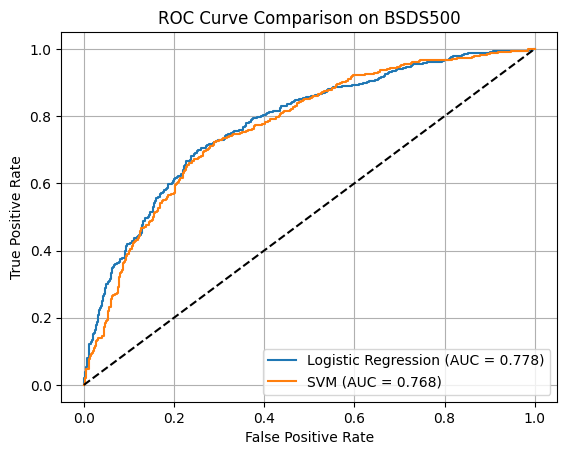

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.io import loadmat
from scipy.ndimage import uniform_filter, sobel, laplace, maximum_filter, minimum_filter
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import kagglehub

path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500")

images = sorted(glob.glob(path + "/**/*.jpg", recursive=True))
gtmap = {}
for m in glob.glob(path + "/**/*.mat", recursive=True):
    gtmap[os.path.basename(m)[:-4]] = m

names = ["Intensity", "Gradient", "LocalMean", "LocalStd", "Laplacian", "Range"]


def get_features(f):
    g = np.array(Image.open(f).convert("L"), dtype=float) / 255.0
    gx = sobel(g, axis=0)
    gy = sobel(g, axis=1)
    grad = np.sqrt(gx * gx + gy * gy)
    mean = uniform_filter(g, 5)
    std = np.sqrt(np.abs(uniform_filter(g * g, 5) - mean * mean))
    lap = np.abs(laplace(g))
    rng = maximum_filter(g, 3) - minimum_filter(g, 3)
    F = np.stack([g, grad, mean, std, lap, rng], axis=2)
    return F.reshape(-1, 6), g.shape


def get_labels(name, shape):
    d = loadmat(gtmap[name])["groundTruth"]
    b = np.zeros(shape)
    for i in range(d.shape[1]):
        b = b + d[0, i]["Boundaries"][0, 0]
    return (b > 0).astype(int).reshape(-1)


def build_dataset(n_images, per_class):
    X = []
    Y = []
    for f in images[:n_images]:
        name = os.path.basename(f)[:-4]
        if name not in gtmap:
            continue
        F, shape = get_features(f)
        L = get_labels(name, shape)
        pos = np.where(L == 1)[0]
        neg = np.where(L == 0)[0]
        k = min(per_class, len(pos), len(neg))
        if k == 0:
            continue
        pos = np.random.choice(pos, k, replace=False)
        neg = np.random.choice(neg, k, replace=False)
        idx = np.concatenate([pos, neg])
        X.append(F[idx])
        Y.append(L[idx])
    return np.vstack(X), np.concatenate(Y)


np.random.seed(1)
X, y = build_dataset(30, 100)
X = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(Xtr), " Testing samples:", len(Xte))

lr = LogisticRegression(max_iter=1000)
lr.fit(Xtr, ytr)
pred_lr = lr.predict(Xte)
score_lr = lr.decision_function(Xte)

svm = SVC(kernel="rbf", C=1.0, gamma="scale")
svm.fit(Xtr, ytr)
pred_svm = svm.predict(Xte)
score_svm = svm.decision_function(Xte)


def evaluate(name, yte, pred, score):
    print("Model:", name)
    print("Confusion Matrix:")
    print(confusion_matrix(yte, pred))
    print("Accuracy  =", round(accuracy_score(yte, pred), 4))
    print("Precision =", round(precision_score(yte, pred), 4))
    print("Recall    =", round(recall_score(yte, pred), 4))
    print("F1 Score  =", round(f1_score(yte, pred), 4))
    print("ROC-AUC   =", round(roc_auc_score(yte, score), 4))
    return [accuracy_score(yte, pred), precision_score(yte, pred), recall_score(yte, pred), f1_score(yte, pred), roc_auc_score(yte, score)]


a = evaluate("Logistic Regression", yte, pred_lr, score_lr)
b = evaluate("Support Vector Machine", yte, pred_svm, score_svm)

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
print("Comparison Table:")
for i in range(len(metrics)):
    print(metrics[i], " LR =", round(a[i], 4), " SVM =", round(b[i], 4))

f1, t1, _ = roc_curve(yte, score_lr)
f2, t2, _ = roc_curve(yte, score_svm)

plt.plot(f1, t1, label="Logistic Regression (AUC = " + str(round(a[4], 3)) + ")")
plt.plot(f2, t2, label="SVM (AUC = " + str(round(b[4], 3)) + ")")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison on BSDS500")
plt.legend()
plt.grid(True)
plt.show()
